# Ejercicio 1: Preparación de los datos para Machine Learning

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.config import LAGOS, RAW_DIR, OUT_DIR
from src.build_dataset import (
    build_full_dataset, GRID_STRIDE, NDWI_WATER_THRESHOLD,
    REFLECTANCE_MIN, REFLECTANCE_MAX, CIANO_MIN, CIANO_MAX,
)

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)


In [2]:
dataset_path = OUT_DIR / "ml_dataset.parquet"

if RAW_DIR.exists() and any(RAW_DIR.glob("*/*.tif")):
    df = build_full_dataset()
    dataset_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(dataset_path, index=False)
    print(f"Dataset reconstruido desde los rasters crudos ({RAW_DIR}) y guardado en {dataset_path}")
else:
    df = pd.read_parquet(dataset_path)
    print(f"No se encontraron rasters crudos en {RAW_DIR}; "
          f"se cargó el dataset ya versionado en {dataset_path}")

df.head()


Dataset reconstruido desde los rasters crudos (/Users/nilsmurallesmorales/universidad/octavosemestre/data/lab42/data/raw) y guardado en /Users/nilsmurallesmorales/universidad/octavosemestre/data/lab42/data/processed/ml_dataset.parquet


,lago,fecha,x_utm,y_utm,lon,lat,green,red,red_edge,nir,ndvi,ndwi,ndci,cianobacteria
0,atitlan,2025-01-18,697115.0,1631225.0,-91.168902,14.747720,0.0096,0.0012,0.0013,0.0005,-0.411765,0.900990,0.040000,4.601613
1,atitlan,2025-01-18,697215.0,1631225.0,-91.167974,14.747712,0.0132,0.0017,0.0030,0.0111,0.734375,0.086420,0.276596,13.319566
2,atitlan,2025-01-18,697465.0,1631125.0,-91.165660,14.746790,0.0117,0.0031,0.0041,0.0024,-0.127273,0.659574,0.138889,5.521066
3,atitlan,2025-01-18,697615.0,1631075.0,-91.164270,14.746327,0.0150,0.0079,0.0083,0.0121,0.210000,0.107011,0.024691,4.445016
4,atitlan,2025-01-18,696765.0,1630975.0,-91.172171,14.745486,0.0309,0.0145,0.0091,0.0265,0.292683,0.076655,-0.228814,-19.415600


### 1.4 Resumen del conjunto de datos

In [3]:
print(f"Número total de observaciones: {len(df):,}")
print(f"Número de lagos: {df['lago'].nunique()} | Número de fechas: {df['fecha'].nunique()}")


Número total de observaciones: 538,675
Número de lagos: 2 | Número de fechas: 20


In [4]:
print("Observaciones por lago:")
display(df.groupby("lago", observed=True).size().rename("n_observaciones"))


Observaciones por lago:


lago
amatitlan     65233
atitlan      473442
Name: n_observaciones, dtype: int64

In [5]:
print("Observaciones por lago y fecha:")
tabla_conteo = (
    df.groupby(["lago", "fecha"], observed=True)
      .size()
      .rename("n_observaciones")
      .reset_index()
      .sort_values(["lago", "fecha"])
)
tabla_conteo


Observaciones por lago y fecha:


,lago,fecha,n_observaciones
0,amatitlan,2025-01-28,6129
1,amatitlan,2025-04-15,6088
2,amatitlan,2025-04-28,5933
3,amatitlan,2025-11-24,6016
4,amatitlan,2026-01-08,5680
5,amatitlan,2026-02-02,5595
6,amatitlan,2026-02-07,5714
7,amatitlan,2026-03-29,6241
8,amatitlan,2026-04-13,6296
9,amatitlan,2026-04-28,5304


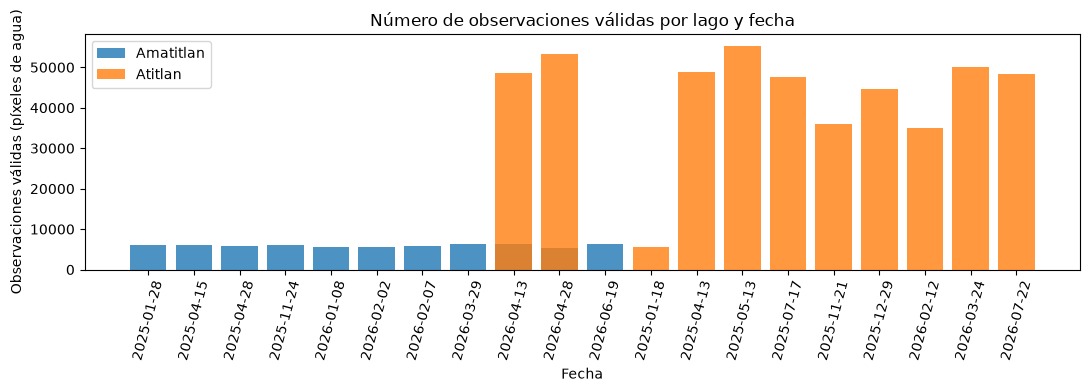

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
for lago, grupo in tabla_conteo.groupby("lago"):
    ax.bar(grupo["fecha"].astype(str), grupo["n_observaciones"], label=lago.capitalize(), alpha=0.8)
ax.set_ylabel("Observaciones válidas (píxeles de agua)")
ax.set_xlabel("Fecha")
ax.set_title("Número de observaciones válidas por lago y fecha")
ax.tick_params(axis="x", rotation=75)
ax.legend()
plt.tight_layout()
plt.show()


In [7]:
tipos = df.dtypes.rename("tipo")
faltantes = (df.isna().mean() * 100).round(3).rename("pct_faltantes")
resumen_vars = pd.concat([tipos, faltantes], axis=1)
resumen_vars


,tipo,pct_faltantes
lago,category,0.0
fecha,datetime64[us],0.0
x_utm,float64,0.0
y_utm,float64,0.0
lon,float64,0.0
lat,float64,0.0
green,float32,0.0
red,float32,0.0
red_edge,float32,0.0
nir,float32,0.0


Como se observa, **no quedan valores faltantes** en ninguna variable

**Variables disponibles:**

| Variable | Tipo | Descripción |
|---|---|---|
| `lago` | categórica | Atitlán o Amatitlán |
| `fecha` | fecha | fecha de adquisición de la escena Sentinel-2 |
| `x_utm`, `y_utm` | numérica (float, metros) | coordenadas en EPSG:32615 (WGS 84 / UTM 15N) |
| `lon`, `lat` | numérica (float, grados) | coordenadas en EPSG:4326, para visualización |
| `green`, `red`, `red_edge`, `nir` | numérica (float, reflectancia 0–1) | bandas Sentinel-2 B03, B04, B05, B08 |
| `ndvi` | numérica (float, -1 a 1) | índice de vegetación |
| `ndwi` | numérica (float, -1 a 1) | índice de agua |
| `ndci` | numérica (float, -1 a 1) | índice normalizado de clorofila (insumo del índice de cianobacteria) |
| `cianobacteria` | numérica (float) | índice/proxy de concentración de clorofila-a (cianobacteria) |


### 1.5 Análisis exploratorio de las variables

In [8]:
vars_num = ["green", "red", "red_edge", "nir", "ndvi", "ndwi", "ndci", "cianobacteria"]
df[vars_num].describe().T


,count,mean,std,min,25%,50%,75%,max
green,538675.0,0.057655,0.162582,0.002500,0.015800,0.021200,0.028300,1.200000
red,538675.0,0.046175,0.161533,0.000100,0.005700,0.010300,0.017500,1.197300
red_edge,538675.0,0.049386,0.167109,0.000100,0.005500,0.010300,0.018900,1.199900
nir,538675.0,0.044241,0.157645,0.000000,0.004500,0.008800,0.016300,1.183200
ndvi,538675.0,-0.051550,0.169402,-1.000000,-0.101449,-0.037209,0.008104,0.941176
ndwi,538675.0,0.408333,0.195477,0.000091,0.269710,0.404922,0.534137,1.000000
ndci,538675.0,0.025637,0.121965,-0.231303,-0.037037,0.003460,0.049724,0.626446
cianobacteria,538675.0,5.089409,10.753213,-19.991730,3.083287,4.134666,4.681155,149.939636


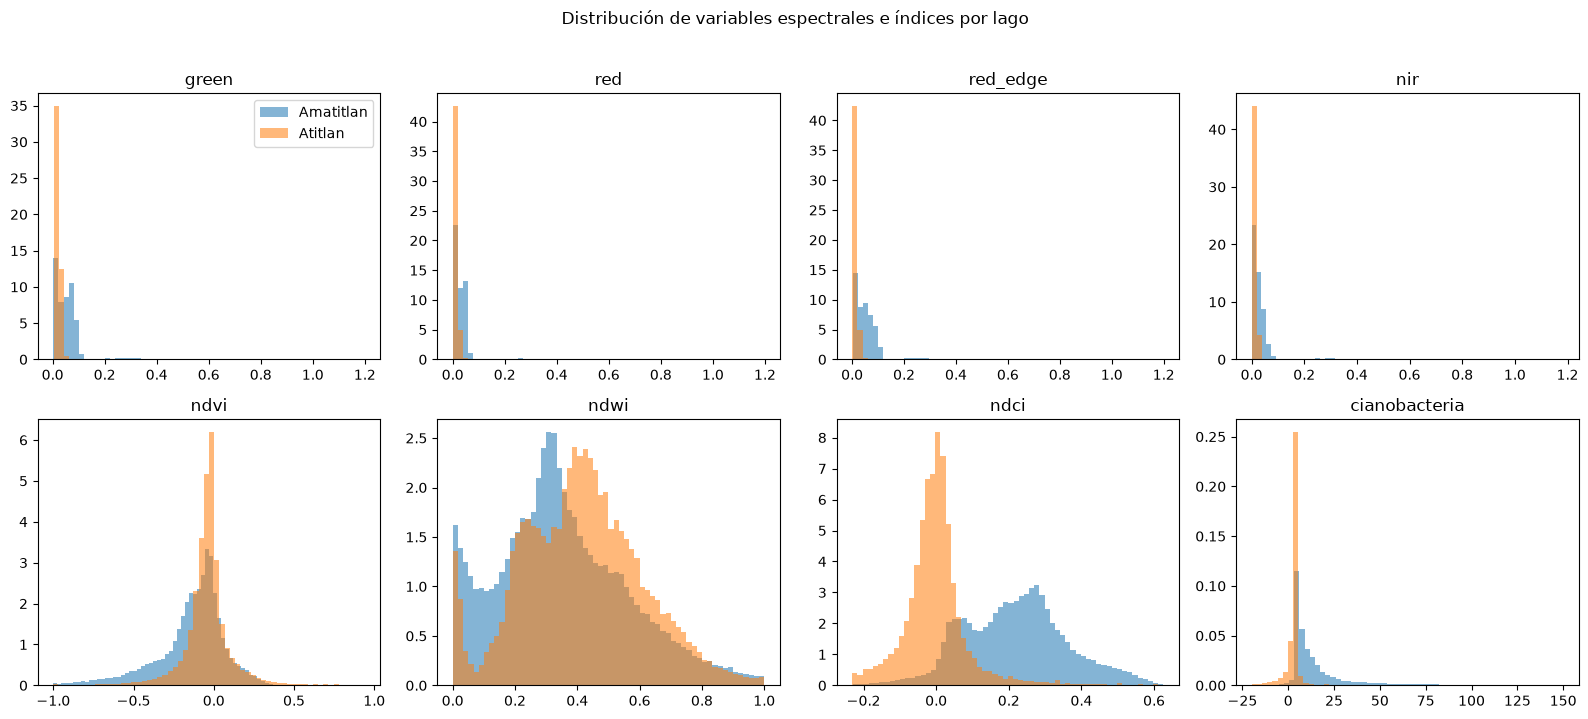

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, var in zip(axes.ravel(), vars_num):
    for lago, grupo in df.groupby("lago", observed=True):
        ax.hist(grupo[var], bins=60, alpha=0.55, density=True, label=lago.capitalize())
    ax.set_title(var)
axes[0, 0].legend()
fig.suptitle("Distribución de variables espectrales e índices por lago", y=1.02)
plt.tight_layout()
plt.show()


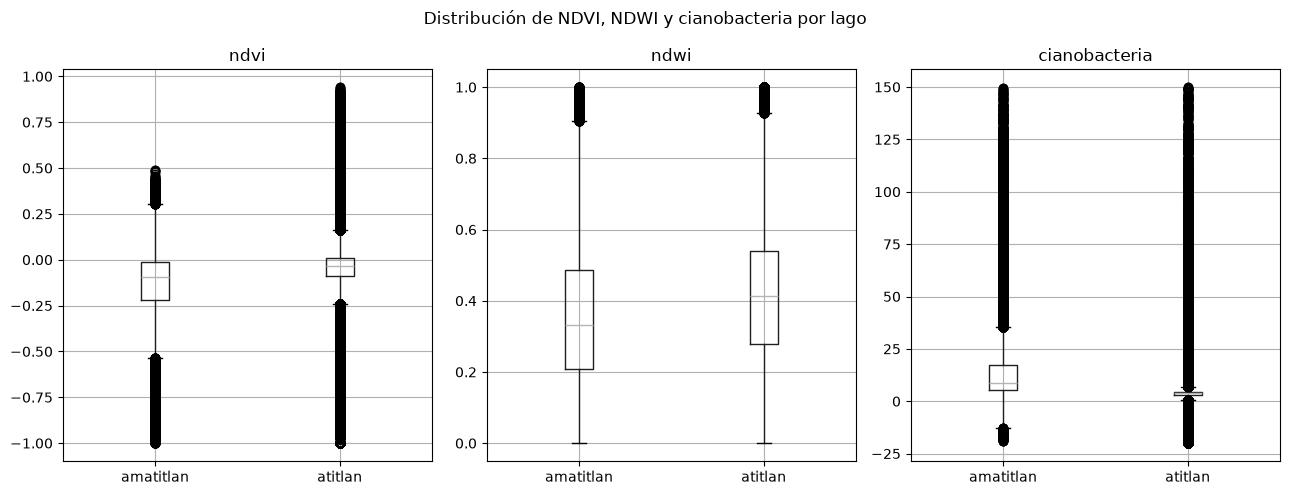

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, var in zip(axes, ["ndvi", "ndwi", "cianobacteria"]):
    df.boxplot(column=var, by="lago", ax=ax)
    ax.set_title(var)
    ax.set_xlabel("")
plt.suptitle("")
fig.suptitle("Distribución de NDVI, NDWI y cianobacteria por lago")
plt.tight_layout()
plt.show()


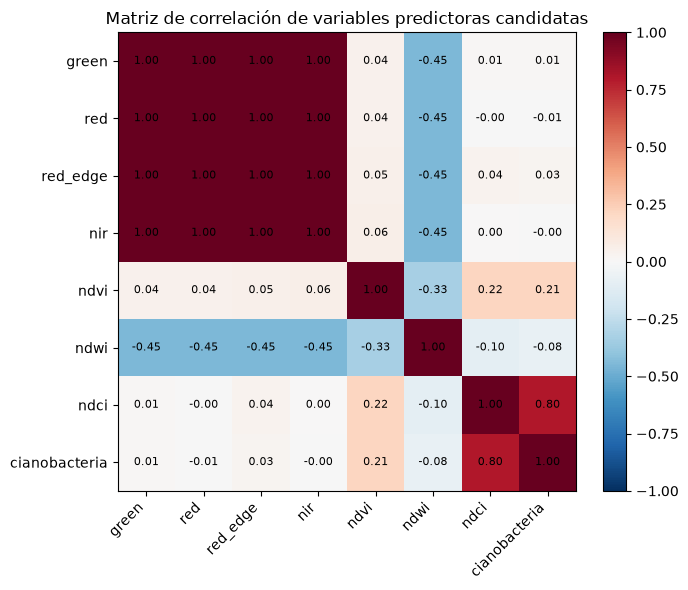

In [11]:
corr = df[vars_num].corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(vars_num))); ax.set_xticklabels(vars_num, rotation=45, ha="right")
ax.set_yticks(range(len(vars_num))); ax.set_yticklabels(vars_num)
for i in range(len(vars_num)):
    for j in range(len(vars_num)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Matriz de correlación de variables predictoras candidatas")
plt.tight_layout()
plt.show()


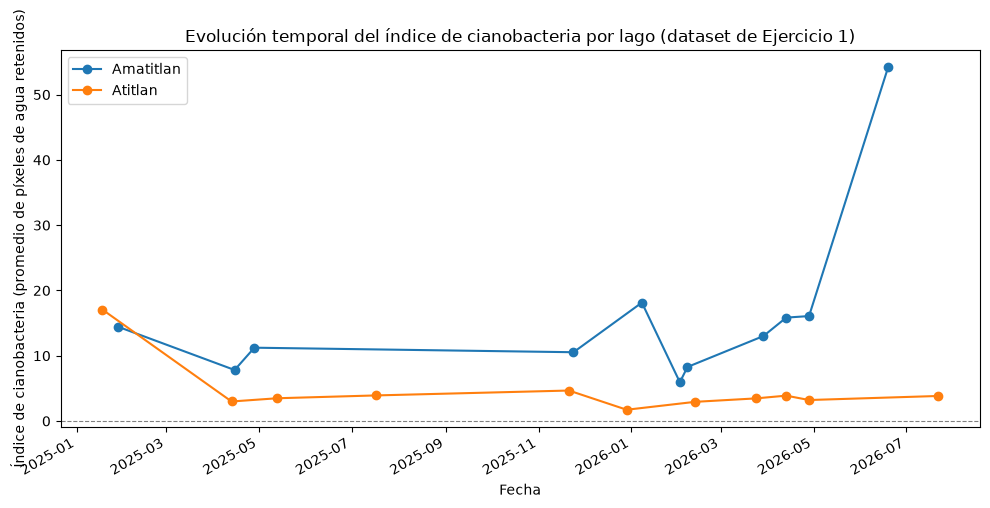

In [12]:
tabla_temporal_propia = (
    df.groupby(["lago", "fecha"], observed=True)[["ndvi", "ndwi", "cianobacteria"]]
      .mean()
      .reset_index()
      .sort_values(["lago", "fecha"])
)

fig, ax = plt.subplots(figsize=(10, 5))
for lago, grupo in tabla_temporal_propia.groupby("lago"):
    ax.plot(grupo["fecha"], grupo["cianobacteria"], marker="o", label=lago.capitalize())
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice de cianobacteria (promedio de píxeles de agua retenidos)")
ax.set_title("Evolución temporal del índice de cianobacteria por lago (dataset de Ejercicio 1)")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


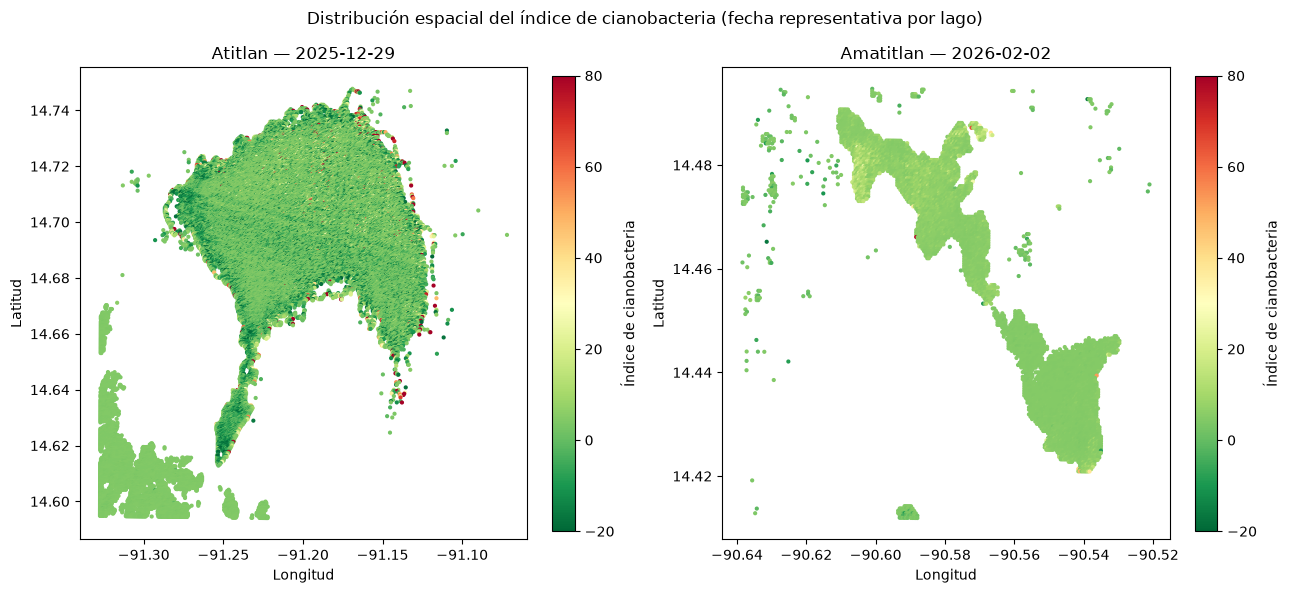

In [13]:
fechas_ejemplo = {lago: fechas[len(fechas) // 2] for lago, fechas in LAGOS.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (lago, fecha) in zip(axes, fechas_ejemplo.items()):
    fecha_ts = pd.Timestamp(fecha)
    sub = df[(df["lago"] == lago) & (df["fecha"] == fecha_ts)]
    sc = ax.scatter(sub["lon"], sub["lat"], c=sub["cianobacteria"], cmap="RdYlGn_r",
                     vmin=CIANO_MIN, vmax=80, s=4)
    ax.set_title(f"{lago.capitalize()} — {fecha}")
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
    fig.colorbar(sc, ax=ax, fraction=0.046, label="Índice de cianobacteria")
fig.suptitle("Distribución espacial del índice de cianobacteria (fecha representativa por lago)")
plt.tight_layout()
plt.show()


Los mapas muestran que las observaciones retenidas cubren de forma razonablemente
uniforme el cuerpo de cada lago (rejilla de 50 m), y que el índice de cianobacteria
tiene estructura espacial clara dentro del lago, no ruido aleatorio. Las zonas
costeras y de menor profundidad tienden a mostrar valores más altos, consistente con
mayor concentración de nutrientes y menor recambio de agua.


### 1.6 Decisiones tomadas durante la preparación y limpieza de los datos

1. Unidad de observación a nivel de píxel (10 m x 10 m), en vez de los promedios
   zonales por lago-fecha de la Parte I: el ejercicio pide una fila por observación
   geográfica válida con coordenadas propias, algo necesario también para la
   validación espacial, la generalización entre lagos y los mapas predictivos de
   ejercicios posteriores.

2. Muestreo sistemático en rejilla de 50 m (paso de 5 píxeles): usar todos los
   píxeles de agua daría entre 2.6 y 13.4 millones de observaciones con
   autocorrelación espacial muy alta entre píxeles vecinos, lo que infla el tamaño
   muestral sin aportar información nueva y sesga la evaluación de los modelos. La
   rejilla de 50 m conserva cobertura completa del lago, reduce esa redundancia y
   deja un dataset manejable (~540 mil filas) para todo el pipeline, incluyendo SHAP.

3. Máscara de agua NDWI > 0: mismo criterio usado en la Parte I cuando no existe un
   polígono oficial del lago.

4. Filtro de reflectancia entre 0 y 1.2: valores negativos o mayores a 1 no son
   físicamente posibles y suelen indicar nubes, brillo especular o artefactos de la
   corrección atmosférica. No se descargó una banda de clasificación de escena en la
   Parte I, así que este filtro es la aproximación disponible para excluir píxeles
   inválidos.

5. Filtro de plausibilidad del índice de cianobacteria entre -20 y 150: el índice es
   un polinomio cúbico del NDCI que se satura cuando este se acerca a ±1,
   produciendo valores no interpretables como concentración real (se observaron
   valores entre -1017 y 673 en los rasters originales). El rango elegido excluye
   esa saturación y conserva un rango fisiológicamente razonable de clorofila-a en
   lagos eutróficos (justificación bibliográfica completa en el Ejercicio 2.2).

6. Coordenadas en dos sistemas: UTM 15N (EPSG:32615) en metros, el mismo que exige
   el Ejercicio 6 para la rejilla espacial, y longitud/latitud (EPSG:4326) para
   visualización.

7. No se eliminaron fechas duplicadas entre lagos: Atitlán y Amatitlán comparten dos
   fechas porque así se definieron en la Parte I; se conservan ambas filas por ser
   escenas y ubicaciones distintas.

8. Variables retenidas pero excluidas como predictoras: NDCI, rojo y red edge
   participan directamente en la fórmula del índice de cianobacteria (variable
   respuesta), por lo que se conservan solo para trazabilidad y no deben usarse como
   predictoras (ver Ejercicio 2.5).
